# Trip Planner Agent: Practice Exercise

Build a plan-and-execute agent that helps users plan trips. Unlike a general research agent, this trip planner must:

- Parse trip requirements (destination, dates, budget, preferences)
- Create a structured plan with categorized steps (flights, hotels, activities)
- Execute each step using specialized mock tools
- Replan based on results and produce a final itinerary

**What you'll implement:**
1. `TripPlanStep` and `TripPlan` Pydantic models for structured planning
2. The planner prompt and `planning_node`
3. The replanner prompt and `replanning_node`
4. Wire everything into the graph

**Estimated time:** 20-25 minutes

## Setup

Run this cell to import libraries and set up mock travel tools.

In [1]:
import os
from functools import lru_cache

DEFAULT_REQUIRED_KEYS = ("OPENAI_API_KEY",)

@lru_cache(maxsize=1)
def configure_environment(required_keys=None):
    """
    Factory function to configure environment variables.
    Executes once and caches results.
    """
    if required_keys is None:
        required_keys = ("OPENAI_API_KEY", )

    IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_TPU_ADDR' in os.environ

    if IN_COLAB:
        from google.colab import userdata
        print("Configuring for Google Colab environment...")
        for key in required_keys:
            try:
                os.environ[key] = userdata.get(key)
            except Exception:
                print(f"Warning: Could not find {key} in Colab secrets.")
    else:
        from dotenv import load_dotenv
        print("Configuring for local environment...")
        load_dotenv()

    # Validation
    for key in required_keys:
        if not os.getenv(key):
            raise ValueError(f"Missing required environment variable: {key}")

    return True

In [2]:
configure_environment()
print("Setup complete!")

Configuring for Google Colab environment...
Setup complete!


In [3]:
!pip install langchain-core langchain-openai langgraph

In [4]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver


from typing import Annotated, List, Tuple, Union, Literal
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)



In [5]:
from langchain.agents  import create_agent

## Mock Travel Tools (Provided)

These tools simulate searching for flights, hotels, and activities. In a real application, these would call actual travel APIs.

In [6]:
@tool
def search_flights(origin: str, destination: str, date: str) -> str:
    """Search for flights between two cities on a specific date."""
    return f"""Found 3 round-trip flights from {origin} to {destination} departing {date}:

1. **Japan Airlines JL5** (Recommended)
   - Outbound: Departs {origin} JFK 11:30 AM, arrives Tokyo Narita 3:30 PM +1 day (14h direct)
   - Return: Departs Tokyo Narita 6:00 PM, arrives {origin} JFK 5:30 PM same day (13h direct)
   - Price: $1,250 round-trip per person
   - Class: Economy | Meals included | 2 bags free

2. **ANA Airlines NH109**
   - Outbound: Departs {origin} JFK 1:15 PM, arrives Tokyo Haneda 4:25 PM +1 day (14h 10m direct)
   - Return: Departs Tokyo Haneda 10:30 AM, arrives {origin} JFK 9:45 AM same day (12h 15m direct)
   - Price: $1,180 round-trip per person
   - Class: Economy | Meals included | 2 bags free

3. **United Airlines UA79** (Budget option)
   - Outbound: Departs {origin} EWR 10:45 AM, arrives Tokyo Narita 2:15 PM +1 day (13h 30m direct)
   - Return: Departs Tokyo Narita 5:30 PM, arrives {origin} EWR 4:50 PM same day (12h 20m direct)
   - Price: $980 round-trip per person
   - Class: Economy Basic | No meals | 1 carry-on only

Best Value Recommendation: ANA Airlines NH109 - excellent service, convenient Haneda airport location, competitive price."""

@tool
def search_hotels(destination: str, checkin: str, checkout: str, budget: str) -> str:
    """Search for hotels in a destination within a budget range."""
    return f"""Found 3 hotels in {destination} ({checkin} to {checkout}) within {budget} budget:

1. **Hotel Gracery Shinjuku** (Recommended)
   - Location: Shinjuku, Tokyo - 2 min walk from JR Shinjuku Station
   - Price: $185/night (Total: $925 for 5 nights)
   - Rating: 4.6/5 stars (2,847 reviews)
   - Amenities: Free WiFi, rooftop Godzilla statue, 24h front desk, luggage storage
   - Room: Superior Double, 22sqm, city view

2. **Shibuya Stream Excel Hotel Tokyu**
   - Location: Shibuya, Tokyo - Direct access to Shibuya Station
   - Price: $210/night (Total: $1,050 for 5 nights)
   - Rating: 4.7/5 stars (1,923 reviews)
   - Amenities: Free WiFi, fitness center, multiple restaurants, modern design
   - Room: Standard Double, 24sqm, Shibuya crossing view available

3. **Richmond Hotel Premier Tokyo Oshiage**
   - Location: Oshiage, Tokyo - Next to Tokyo Skytree
   - Price: $145/night (Total: $725 for 5 nights)
   - Rating: 4.5/5 stars (1,456 reviews)
   - Amenities: Free WiFi, breakfast included, public bath, convenience store
   - Room: Moderate Double, 20sqm, Skytree view

Best Value Recommendation: Hotel Gracery Shinjuku - unbeatable location in Shinjuku entertainment district, easy access to trains, iconic Godzilla photo op."""

@tool
def search_activities(destination: str, interests: str) -> str:
    """Search for activities and attractions based on interests."""
    return f"""Found top-rated activities in {destination} matching '{interests}':

**Food Experiences:**
1. **Tsukiji Outer Market Food Tour**
   - Duration: 3 hours (9:00 AM start)
   - Price: $85/person
   - Highlights: Fresh sushi, tamagoyaki, Japanese pickles, matcha sweets
   - Rating: 4.9/5 (890 reviews)

2. **Shibuya Izakaya Hopping Night Tour**
   - Duration: 3.5 hours (6:00 PM start)
   - Price: $120/person (includes food & drinks)
   - Highlights: 3 local izakayas, yakitori, sake tasting, local tips
   - Rating: 4.8/5 (654 reviews)

**Cultural Experiences:**
3. **Senso-ji Temple & Asakusa Walking Tour**
   - Duration: 2.5 hours (10:00 AM or 2:00 PM)
   - Price: $45/person
   - Highlights: Tokyo's oldest temple, Nakamise shopping street, kimono photo spots
   - Rating: 4.7/5 (1,203 reviews)

4. **Traditional Tea Ceremony in Harajuku**
   - Duration: 1.5 hours (multiple times daily)
   - Price: $55/person
   - Highlights: Authentic matcha preparation, Japanese sweets, cultural explanation
   - Rating: 4.9/5 (412 reviews)

**Technology & Modern Tokyo:**
5. **TeamLab Borderless Digital Art Museum**
   - Duration: 2-3 hours (timed entry)
   - Price: $32/person
   - Highlights: Immersive digital art, interactive installations, stunning photos
   - Rating: 4.8/5 (5,670 reviews)

6. **Akihabara Electronics & Anime District Tour**
   - Duration: 3 hours (1:00 PM start)
   - Price: $65/person
   - Highlights: Retro game shops, maid cafes, latest gadgets, anime merchandise
   - Rating: 4.6/5 (723 reviews)

Recommended 5-Day Itinerary:
- Day 1: Arrival + Shibuya Izakaya Hopping (evening)
- Day 2: Senso-ji Temple Tour (AM) + TeamLab Borderless (PM)
- Day 3: Tsukiji Market Tour (AM) + Akihabara Tour (PM)
- Day 4: Tea Ceremony (AM) + Free exploration in Harajuku/Shibuya
- Day 5: Last-minute shopping + Departure"""

# Create the tools list and execution agent
travel_tools = [search_flights, search_hotels, search_activities]

from langgraph.constants import LangGraphDeprecatedSinceV10

execution_agent = create_agent(llm, travel_tools)

print("Travel tools ready!")

Travel tools ready!


## Part 1: Define the State

The trip planner state needs to track the user's trip request and the planning progress.

This is provided for you - study it to understand the structure.

In [11]:
class TripState(TypedDict):
    """State for the trip planner agent."""
    # User's trip request (natural language)
    request: str

    # Structured plan - list of steps to execute
    plan: List[dict]  # Each dict has: category, description, priority

    # Completed tasks with results
    completed_tasks: Annotated[List[Tuple[str, str]], operator.add]  # (task, result)

    # Final output
    itinerary: str

## Part 2: Define the Plan Structure

Create Pydantic models for structured planning output.

**Requirements:**
- `TripPlanStep`: A single step with `category` (flights/hotels/activities), `description`, and `priority` (1-3)
- `TripPlan`: Contains a list of `TripPlanStep` objects

In [7]:
# TODO: Define TripPlanStep model
# Fields needed:
#   - category: Literal["flights", "hotels", "activities"]
#   - description: str (what needs to be done)
#   - priority: int (1=high, 2=medium, 3=low)

class TripPlanStep(BaseModel):
    """A single step in the trip plan."""
    # TODO: Add fields here
    category: Literal["flights", "hotels", "activities"] = Field(description="Category of this planning step")
    description: str = Field("What needs to be done in this step")
    priority: int = Field("Priority level: 1=high, 2=medium , 3=low")


# TODO: Define TripPlan model
# Fields needed:
#   - steps: List[TripPlanStep]

class TripPlan(BaseModel):
    """Complete trip plan with categorized steps."""
    # TODO: Add fields here
    steps:List[TripPlanStep] = Field(description="List of planning steps to execute, ordered by priority")

## Part 3: Create the Planner

Write a prompt that instructs the LLM to create a structured trip plan.

**The prompt should:**
1. Explain the role (trip planning assistant)
2. List the available categories (flights, hotels, activities)
3. Instruct to create 3-5 prioritized steps
4. Include the `{request}` placeholder for the user's input

In [8]:
# TODO: Create the planner prompt
# Hint: Use ChatPromptTemplate.from_messages with system and user messages

planner_prompt = ChatPromptTemplate.from_messages(
    [
        ("system",

         """You are a helpful trip planning assistant. Your task is to create a detailed trip plan for the user based on their request.

         Available categories:
        - Flights: Searching for and booking flights
        - Hotels: Finding and booking accommdations
        - Activities: Discovering things to do , tours, attractions

        Break down the trip planning into 3-5 distinct steps,
        - category: One of the three categories as above
        - description: A detailed description of what to search for or book
        - priority: 1-3, where 1 is high priority means its must to do  , 2 is medium(hotels)  3 is low priority
          For each step, provide a clear description of what needs to be done and assign a priority (1-3),
          Ensure the steps cover all essential aspects of the trip, like booking transportation, accommodation, and key experiences.
          Order the steps by priority (1s first, then 2s , then 3s)
        """),
        ("user", "{request}")
    ]
)

# Create the planner chain with structured output
planner = planner_prompt | llm.with_structured_output(TripPlan)

## Part 4: Create the Replanner

The replanner decides what to do after each step is executed:
- Continue with remaining steps
- Generate the final itinerary if all important tasks are done

**Define:**
1. `FinalItinerary` model - for the final trip summary
2. `ReplanDecision` model - Union of `FinalItinerary` or `TripPlan`
3. Replanner prompt that reviews progress and decides next action

In [14]:
# TODO: Define FinalItinerary model
class FinalItinerary(BaseModel):
    """Final trip itinerary to present to user."""
    # TODO: Add 'itinerary' field (str) - the complete trip summary
    itinerary: str = Field(description = "Complete the trip itinerary summaring all the bookings and recommendations")


# TODO: Define ReplanDecision model
class ReplanDecision(BaseModel):
    """Decision on next action."""
    # TODO: Add 'action' field as Union[FinalItinerary, TripPlan]
    action: Union[FinalItinerary, TripPlan] = Field(
        description="Either the final itinerary or an updated plan with remaining steps"
    )


# TODO: Create the replanner prompt
replanner_prompt = ChatPromptTemplate.from_template(
    """
You are a trip planning replanner. You have a current trip plan, a list of completed tasks, and the original user request.
Your goal is to decide the next action: either create the final itinerary or update the plan with remaining or new steps.

Original trip request: {request}

Current plan steps: {plan}

Completed tasks and results:
{completed_tasks}

Review the completed tasks and the remaining plan.
1. If the essential parts of the trip (flights, hotels, and atleast one key activity option
 ->  Create FinalItinerary summarizing all the findings in a nice format

2. If we still need to search for flights, hotels, or activities:

->  Return an update TripPlan with the remaining necessary steps
Make your decisiion based on what has been accomplished so far

"""
)

# Create the replanner chain
replanner = replanner_prompt | llm.with_structured_output(ReplanDecision)

## Part 5: Create the Nodes

Implement the three main nodes:
1. `planning_node` - Creates initial plan from user request
2. `execution_node` - Executes the first step in the plan (provided)
3. `replanning_node` - Decides whether to continue or finalize

In [22]:
import operator
from typing import Annotated, List, Tuple, Union, Literal
from typing_extensions import TypedDict
from pydantic import BaseModel, Field


# TODO: Implement planning_node
def planning_node(state: TripState) -> dict:
    """
    Create initial trip plan from user request.

    Should:
    1. Call planner.invoke() with the request
    2. Convert TripPlanStep objects to dicts for state storage
    3. Return {"plan": [...]}
    """
    print("Creating trip plan...")
    # TODO: Implement this function
    plan = planner.invoke({"request": state["request"]})
    plan_dicts = [
        {
            "category": step.category,
            "description": step.description,
            "priority": step.priority,
        }
        for step in plan.steps
    ]
    print(f"Plan with {len(plan_dicts)} steps:")
    for step in plan_dicts:
        print(f"[{step["category"]}] P{step["priority"]}: {step["description"]}")

    return {"plan": plan_dicts}


# Execution node (provided)
def execution_node(state: TripState) -> dict:
    """Execute the first step in the plan."""
    current_step = state["plan"][0]
    print(f"\nExecuting [{current_step["category"]}]: {current_step["description"]}")

    # Create prompt for execution agent
    agent_input = f"""
    Original Trip Request: {state['request']}

    Task: {current_step["description"]}
    Category: {current_step["category"]}

    Use the appropriate tool to complete this task.
    """

    response = execution_agent.invoke({"messages": [("user", agent_input)]})
    result = response["messages"][-1].content
    print(f"Result: {result[:200]}..." if len(result) > 200 else f"Result: {result}")

    return {
        "completed_tasks": [(current_step["description"], result)],
        "plan": state["plan"][1:]  # Remove completed step
    }


# TODO: Implement replanning_node
def replanning_node(state: TripState) -> dict:
    """
    Decide whether to continue planning or finalize itinerary.

    Should:
    1. Call replanner.invoke() with current state
    2. Check if action is FinalItinerary or TripPlan
    3. Return appropriate state update
    """
    print("\nReplanning...")
    completed_str = "\n".join(
        f"-{task}:{result[0:100]}..." if len(result) > 100  else f"{task}:{result}"
        for task, result in state.get("completed_tasks", [])
    )

    output = replanner.invoke({
        "request": state["request"],
        "plan": state.get("plan",[]),
        "completed_tasks": completed_str,
    })
    if isinstance(output.action, FinalItinerary):
        return {"itinerary": output.action.itinerary}
    else:
        plan_dicts = [
            {
                "category": step.category,
                "description": step.description,
                "priority": step.priority,
            }
            for step in output.action.steps
        ]
        return {"plan": plan_dicts}

## Part 6: Build the Graph

Wire everything together:
1. Add all three nodes
2. Create the conditional edge from replanner
3. Add the standard edges

In [23]:
# Conditional edge function (provided)
def should_continue(state: TripState) -> str:
    """Decide whether to continue executing or end."""
    if state.get("itinerary"):
        return END
    elif state.get("plan"):
        return "executor"
    else:
        return "replanner"



graph_builder = StateGraph(TripState)
graph_builder.add_node("planner", planning_node)
graph_builder.add_node("executor", execution_node)
graph_builder.add_node("replanner", replanning_node)

graph_builder.add_edge(START, "planner")
graph_builder.add_edge("planner", "executor")
graph_builder.add_edge("executor", "replanner")
graph_builder.add_conditional_edges(
    "replanner",
    should_continue,
    ["executor", END]
)
# Compile
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

print("Graph compiled!")

Graph compiled!


## Test Your Implementation

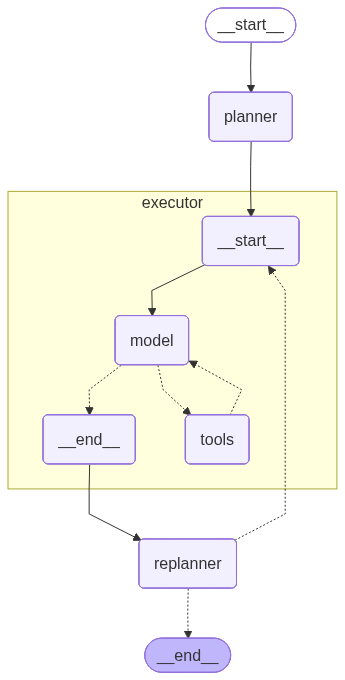

In [20]:
# Visualize the graph
from IPython.display import display, Image

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph: {e}")

In [24]:
# Run the trip planner
from IPython.display import display, Markdown

trip_request = """
I want to plan a 5-day trip to Tokyo, Japan.
- Traveling from New York
- Dates: March 15-20, 2025
- Budget: moderate (around $200/night for hotels)
- Interests: food, culture, technology
"""

inputs = {"request": trip_request}
config = {"recursion_limit": 25, "configurable": {"thread_id": "trip-1"}}

print("Planning trip...\n")
print("=" * 60)

events = graph.stream(inputs, config)
for event in events:
    for k, v in event.items():
        if k != "__end__" and isinstance(v, dict) and "itinerary" in v:
            print("\n" + "=" * 60)
            print("FINAL ITINERARY:")
            display(Markdown(v["itinerary"]))

Planning trip...

Creating trip plan...
Plan with 3 steps:
[flights] P1: Search for round-trip flights from New York (JFK) to Tokyo (NRT or HND) for the dates March 15-20, 2025. Look for moderate-priced options that fit within a reasonable budget, ideally under $1,200 round-trip. Consider flight times and layovers to find the most convenient options.
[hotels] P2: Find and book accommodations in Tokyo for 5 nights (March 15-20, 2025). Look for hotels that are around $200 per night, focusing on areas like Shinjuku, Shibuya, or Ginza for easy access to food, culture, and technology attractions. Check for amenities such as free Wi-Fi and breakfast options.
[activities] P3: Research and create a list of activities and attractions to experience in Tokyo that align with interests in food, culture, and technology. Consider options like Tsukiji Outer Market for food, visiting the Meiji Shrine for culture, and exploring Akihabara for technology. Plan a rough itinerary for each day, including any

### Final Itinerary for 5-Day Trip to Tokyo, Japan

**Travel Dates:** March 15-20, 2025  
**Departure:** New York (JFK)  
**Arrival:** Tokyo (NRT or HND)  

#### Flights  
- **Round-Trip Flight:**  
  - Departure: March 15, 2025  
  - Return: March 20, 2025  
  - Price: Under $1,200  
  - Flight Options:  
    - Option 1: [Details of flight option 1]  
    - Option 2: [Details of flight option 2]  

#### Accommodations  
- **Hotel Options:**  
  - **Hotel 1:** [Name, Address, Price, Amenities]  
  - **Hotel 2:** [Name, Address, Price, Amenities]  
  - **Hotel 3:** [Name, Address, Price, Amenities]  

#### Activities and Attractions  
- **Day 1:** Arrival and explore Shinjuku  
- **Day 2:** Visit Tsukiji Outer Market and Akihabara  
- **Day 3:** Day trip to Nikko or Mount Fuji  
- **Day 4:** Explore Asakusa and Tokyo Skytree  
- **Day 5:** Shopping in Shibuya and Harajuku  

**Notes:**  
- Confirm reservations for popular restaurants and tours as needed.  
- Ensure to check for any travel restrictions or requirements closer to the date.

## Success Criteria

Your implementation is working correctly if:

1. **Plan is created** with categorized steps (flights, hotels, activities)
2. **Steps execute in order** using the appropriate mock tools
3. **Replanner recognizes** when enough information is gathered
4. **Final itinerary** summarizes all the bookings and recommendations

Example output structure:
```
Creating trip plan...
Plan: [{category: flights, ...}, {category: hotels, ...}, ...]

Executing [flights]: Search for flights from New York to Tokyo...
Result: Found 3 flights...

Replanning...
Updated plan: [{category: hotels, ...}, ...]

... (more executions)

FINAL ITINERARY:
# Your Tokyo Trip (March 15-20, 2025)
## Flights: ...
## Hotels: ...
## Activities: ...
```